# FUGA FLOWERS

Fuga is wake model which precomputes the normalized wake for a turbine using RANS. This precomputation is stored in a look-up table (LUT). Before the final step, results are stored in fourier spatial coefficients in the (FLUT). Using similar derivations to those used in NO Jensen FLOWERS (Linear Sumation) and Gaussian Bastankhah Porte-Agel FLOWERS (Binomial Expansion), it is possible to compute AEP using the fuga wake model with a FLOWERS implementation. This notebook describes the two, or four, options to compute AEP using this combintation of AEP and wake model.

A detailed derivation of the methods can be found in the [refer to theory] file.

Package imports

In [1]:
from FLOWERS.fuga import fuga_flowers
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
from py_wake.literature.fuga import Ott_Nielsen_2014, Ott_Nielsen_2014_Blockage
import time
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Ignore numerical errors coming from FLOWERS (division by zero, etc.)
import warnings
warnings.filterwarnings("ignore")

c:\Users\janbu\AppData\Local\anaconda3\envs\flowers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initialized AEP conditions

In [5]:
site = Hornsrev1Site()
turbine = V80()
x, y = Hornsrev1Site().initial_position.T

# LUT and FLUTS paths
# This LUTS and FLUTS are generated using pyfuga, and correspond to the V80 turbine
data_directory = Path.cwd().parent / "data"
FLUT_PATH = str(data_directory / "fLUTs_Zeta0=0.00e+00_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL.nc")
LUT_PATH = str(data_directory / "LUTs_Zeta0=0.00e+00_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.NC")

## Create fuga wind farm models

Similar to the other FLOWERS models, the number of Fourier terms (`n_terms`) determines the accuracy of the model, as well as the computational time. However, the wake model here is implemented based on what may be referred to as a "look-up table of Fourier modes". The number of Fourier term therefore also affects the accuracy with which the approximation of the wake model using Fourier resembles that coming from the original LUT. More on this later.

In this case `HornsrevSite` has 12 wind direction bins, so the maximum number of Fourier terms is 7. 

Depending on how the epxanison of the cubic term is approached to solve the integral analytically, we can differentiate two different ways of doing fuga FLOWERS (`method="linear"` or `method="binomial"`), each one with their respective LUT and FLUTs implementation (`source="lut"` or `source="flut"`), therefore 4 options in total. 

**Using LUTs**


This corresponds to using the output LUT from `pyfuga`, being the `lut_file=LUT_PATH` and `source="lut"`. In this case, the model generates a LUT of Fourier modes, which, for a distance `r_ij` reconstruct the turbine's interaction for the entire 360 degrees surrounding the wake-generating turbine. The model uses the Fourier modes for every turbine `i`and `j` to determine the deficit and compute the AEP.

In [6]:
# Summing linearly
time_start = time.time()
wfm_fuga_flowers_LUT = fuga_flowers(site=site,
                                    windTurbines=turbine, 
                                    lut_file=LUT_PATH,
                                    source="lut",
                                    n_terms=7)
print(f"FLOWERS (LUT) initialized in {time.time() - time_start:.5f} seconds")

# Expanding the binomial
wfm_fuga_flowers_binomial_LUT = fuga_flowers(site=site,
                                            windTurbines=turbine, 
                                            lut_file=LUT_PATH,
                                            source="lut",
                                            n_terms=7,
                                            method="binomial")

print(f"FLOWERS (LUT, binomial expansion) initialized in {time.time() - time_start:.5f} seconds")

FLOWERS (LUT) initialized in 0.84930 seconds
FLOWERS (LUT, binomial expansion) initialized in 1.29474 seconds


**Using FLUTs (Fourier Look-Up Table)**


This corresponds to using the output FLUT from pyfuga, being the `lut_file=FLUT_PATH` and `source="flut"`. In this case, an angular Fourier transform and then a Hankel transform turn the FLUT into a similar LUT of Fourier coefficients to reconstruct the turbine interactions, and then used in a similar way as in the LUTs case. This process takes longer to initialize than the LUT method.

In [7]:
# Summing linearly
time_start = time.time()
wfm_fuga_flowers_FLUT = fuga_flowers(site=site,
                                    windTurbines=turbine, 
                                    lut_file=FLUT_PATH,
                                    source="flut",
                                    n_terms=7)
print(f"FLOWERS (FLUT) initialized in {time.time() - time_start:.5f} seconds")

# Expanding the binomial
time_start = time.time()
wfm_fuga_flowers_binomial_FLUT = fuga_flowers(site=site,
                                            windTurbines=turbine, 
                                            lut_file=FLUT_PATH,
                                            source="flut",
                                            n_terms=7,
                                            method="binomial")
print(f"FLOWERS (FLUT, binomial expansion) initialized in {time.time() - time_start:.5f} seconds")

FLOWERS (FLUT) initialized in 14.92112 seconds
FLOWERS (FLUT, binomial expansion) initialized in 12.63824 seconds


**PyWake**

In [8]:
wfm_fuga = Ott_Nielsen_2014(site=site, 
                            windTurbines=turbine, 
                            LUT_path=LUT_PATH)

### Compute wind farm AEP

The wind farm AEP can be computed using the `aep` function. Each approach, linear sum or binomial expansion, should yield very similar results for its two methods LUT and FLUT.

In [9]:
# Summing linearly
print("When summing linearly:")
time_start = time.time()
AEP_LUT = wfm_fuga_flowers_LUT.aep(x, y)
print(f"AEP (LUT) = {AEP_LUT:.2f} GWh, computed in {time.time() - time_start:.5f} seconds")

time_start = time.time()
AEP_FLUT = wfm_fuga_flowers_FLUT.aep(x, y)
print(f"AEP (FLUT) = {AEP_FLUT:.2f} GWh, computed in {time.time() - time_start:.5f} seconds")

# Expanding the binomial
print()
print("When expanding the binomial:")
time_start = time.time()
AEP_LUT_binomial = wfm_fuga_flowers_binomial_LUT.aep(x, y)
print(f"AEP (LUT) = {AEP_LUT_binomial:.2f} GWh, computed in {time.time() - time_start:.5f} seconds")

time_start = time.time()
AEP_FLUT_binomial = wfm_fuga_flowers_binomial_FLUT.aep(x, y)
print(f"AEP (FLUT) = {AEP_FLUT_binomial:.2f} GWh, computed in {time.time() - time_start:.5f} seconds")

When summing linearly:
AEP (LUT) = 568.02 GWh, computed in 0.00591 seconds
AEP (FLUT) = 570.23 GWh, computed in 0.00545 seconds

When expanding the binomial:
AEP (LUT) = 566.09 GWh, computed in 0.00484 seconds
AEP (FLUT) = 569.02 GWh, computed in 0.00511 seconds


When compared to those results using PyWake, it can be seen how both of them are considerably faster, although with a significant difference in the AEP estimation

In [10]:
time_start = time.time()
sim_res = wfm_fuga(x, y,
                    wd=site.default_wd,
                    ws=site.default_ws)

AEP_fuga = sim_res.aep().sum().values
print(f"AEP (PyWake) = {AEP_fuga:.2f} GWh, computed in {time.time() - time_start:.5f} seconds")

AEP (PyWake) = 664.85 GWh, computed in 0.45659 seconds


Gradients and AEP for a specific turbine can be computed in a similar way to the other methods, as shown in [refer to aep and gradients notebook].

### Sensitivity to number of Fourier modes

The number of Fourier modes (`n_terms`) determines the accuracy of the AEP, in addition to the accuracy with which the turbine interactions are reconstructed using the Fourier series. Here is an example of the AEP and reconstruction for different number of modes, using the LUTs and the linear summation. A new wind rose is used to enable a higher resolution.

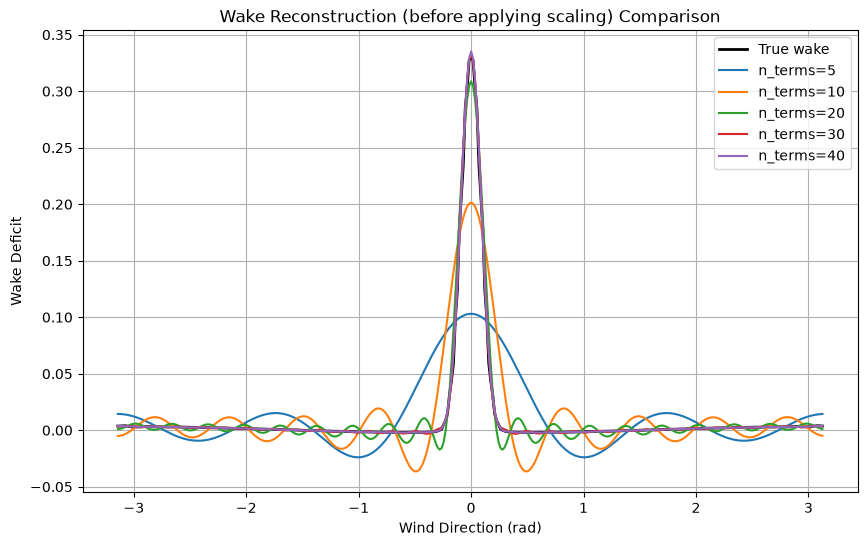

In [11]:
# Import new wind rose with 360 WD bins resolution
from utils import generic_site
site = generic_site(10)

# LUT_PATH = str(data_directory / "stability" / "LUTs_Zeta0=0.00e+00_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.NC")

# Obtain real wake for a distance D
wfm_fuga_flowers_LUT = fuga_flowers(site=site,
                                    windTurbines=turbine,
                                    lut_file=LUT_PATH,
                                    source="lut",
                                    n_terms=20)
D = 5  # Diamaters
alpha = np.linspace(-np.pi, np.pi, 360, endpoint=False)
g_true = wfm_fuga_flowers_LUT._LUT(np.broadcast_to(D, alpha.shape), alpha)


def reconstruct_wake(n_terms):
    wfm = fuga_flowers(site=site,
                       windTurbines=turbine,
                       lut_file=LUT_PATH,
                       source="lut",
                       n_terms=n_terms,
                       n_alpha=360)
    
    A =  wfm._eval_mode_interpolators(wfm._A_interpolator, np.array([[D]]))
    B =  wfm._eval_mode_interpolators(wfm._B_interpolator, np.array([[D]]))
    A = A[0,0]; B = B[0,0]
    m = np.arange(len(A))
    g = A[0]/2 + (A[1:]*np.cos(m[1:]*alpha[:,None]) + B[1:]*np.sin(m[1:]*alpha[:,None])).sum(1)
    return g

n_terms = [5, 10, 20, 30, 40]

g_reconstructed = [reconstruct_wake(n) for n in n_terms]


# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(alpha, g_true, label="True wake", color="black", linewidth=2)
for n, g in zip(n_terms, g_reconstructed):
    plt.plot(alpha, g, label=f"n_terms={n}")
plt.xlabel("Wind Direction (rad)")
plt.ylabel("Wake Deficit")
plt.title("Wake Reconstruction (before applying scaling) Comparison")
plt.legend()
plt.grid(True)
plt.show()

It is noticed how above 20 terms the wake is fairly reconstructed, with 30 and 40 modes being identical to the reference. However, its effects in the overal AEP estimation are negligible, we will now see.

In [12]:
def aep_modes(n_terms, time_it=False):
    wfm = fuga_flowers(site=site,
                       windTurbines=turbine,
                       lut_file=LUT_PATH,
                       source="lut",
                       n_terms=n_terms)

    time_start = time.time()
    AEP = wfm.aep(x, y)
    time_elapsed = time.time() - time_start
    if time_it:
        return time_elapsed
    else:
        return AEP

AEP_modes = [aep_modes(n) for n in n_terms]
print("AEP for different number of modes (using 10 modes as reference):")
for n, AEP in zip(n_terms, AEP_modes):
    print(f"n_terms={n}: AEP = {AEP:.2f} GWh, relative error = {100*(AEP-AEP_modes[1])/AEP_modes[1]:.3f}%")

AEP for different number of modes (using 10 modes as reference):
n_terms=5: AEP = 687.05 GWh, relative error = -0.014%
n_terms=10: AEP = 687.14 GWh, relative error = 0.000%
n_terms=20: AEP = 687.08 GWh, relative error = -0.009%
n_terms=30: AEP = 687.33 GWh, relative error = 0.028%
n_terms=40: AEP = 687.38 GWh, relative error = 0.035%


However, there is an effect in the computational costs:


In [13]:
time_modes = [aep_modes(n, time_it=True) for n in n_terms]
print("Computation time for different number of modes (using 10 modes as reference):")
for n, t in zip(n_terms, time_modes):
    print(f"n_terms={n}: time = {t:.5f} seconds, relative difference = {100*(t-time_modes[1])/time_modes[1]:.2f}%")

Computation time for different number of modes (using 10 modes as reference):
n_terms=5: time = 0.00583 seconds, relative difference = -24.49%
n_terms=10: time = 0.00772 seconds, relative difference = 0.00%
n_terms=20: time = 0.01570 seconds, relative difference = 103.32%
n_terms=30: time = 0.02685 seconds, relative difference = 247.84%
n_terms=40: time = 0.03509 seconds, relative difference = 354.59%


## Including atmospheric stability into the AEP compuation

**This feature is still under research and development**

In this examples, 5 atmospheric stability conditions are considered, referred to as Very Unstable (`VU`), Unstable (`U`), Neutral (`N`), Stable (`S`) and Very Stable (`VS`).

First, we have to import the data and create the different models for each stability scenario (to be improved).

In [14]:
import pandas as pd

# Import examples stability rose
stability_rose = pd.read_csv(data_directory / "stability_rose_wind_speed.csv", index_col=0)

# Import fuga LUT files for different stability scenarios
LUT_PATH_VU = str(data_directory / "stability" / "LUTs_Zeta0=-2.00e-07_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.nc")
LUT_PATH_U = str(data_directory / "stability" / "LUTs_Zeta0=-1.00e-06_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.nc")
LUT_PATH_N = str(data_directory / "stability" / "LUTs_Zeta0=0.00e+00_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.nc")
LUT_PATH_S = str(data_directory / "stability" / "LUTs_Zeta0=1.00e-06_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.nc")
LUT_PATH_VS = str(data_directory / "stability" / "LUTs_Zeta0=2.00e-07_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_UL_nx2048_ny512_dx20_dy5.nc")

flowers_stability_models = {}

# For each atmospheric stability considered, a FLOWERS model is created and stored in a dictionary
time_i = time.time()

for stability, lut_path in zip(["VU", "U", "N", "S", "VS"],
                             [LUT_PATH_VU, LUT_PATH_U, LUT_PATH_N, LUT_PATH_S, LUT_PATH_VS]):

    # Get the frequency of occurrence of the stability condition from the stability rose
    stability_freqs = stability_rose[stability].values

    # Create a FLOWERS model for the current stability condition using the corresponding LUT file
    flowers_stability = fuga_flowers(site=site,
                                     windTurbines=turbine,
                                     lut_file=lut_path,
                                     source="lut",
                                     stability_conditions_prob=stability_freqs)

    # Store the FLOWERS model for the current stability condition in the dictionary
    flowers_stability_models[stability] = flowers_stability

time_f = time.time()
print(f"FLOWERS models built in: {time_f - time_i:.5f} s")

FLOWERS models built in: 1.86934 s


Now a function to compute AEP is created, in which only $\overline{\Delta p_{\infty}}(r_{ij}, \theta_{ij})$ is dependent on the atmoshperic stability, so it needs to be computed for each case.

In [15]:
def aep_with_stability(x, y):

    aep_stability = []

    # Compute delta p for each stability condition
    for stability in ["VU", "U", "N", "S", "VS"]:

        delta_p = flowers_stability_models[stability]._calculate_delta_p(x, y)
        aep_stability.append(delta_p)

    aep_stability = np.array(aep_stability)

    # Compute the AEP per turbine considering free stream AEP and wake loses
    # np.sum(aep_stability, axis=0) computes the losses coming from all stability conditions considered
    aep_total = (flowers_stability.p_hat - np.sum(aep_stability, axis=0))**3

    # Return dimensions in GWh
    aep_total = aep_total * 25**3 * 8760 * np.pi/8 * 1.225 * 80**2 / 1e9

    # Sum up AEP from all turbines
    aep_total = np.sum(aep_total)

    return aep_total

Comparison with regular FLOWERS (using neutral conditions)

In [16]:
# AEP using only neutral conditions
time_start = time.time()
AEP_neutral = wfm_fuga_flowers_LUT.aep(x, y)
time_elapsed_neutral = time.time() - time_start
print(f"AEP (neutral conditions) = {AEP_neutral:.2f} GWh, computed in {time_elapsed_neutral:.5f} seconds")

# AEP considering all stability conditions
time_start = time.time()
AEP_stability = aep_with_stability(x, y)
time_elapsed_stability = time.time() - time_start
print(f"AEP (all stability conditions) = {AEP_stability:.2f} GWh, computed in {time_elapsed_stability:.5f} seconds")
print()
print(f"FLOWERS with stability took {time_elapsed_stability/time_elapsed_neutral:.2f} times longer than the neutral conditions")

AEP (neutral conditions) = 687.08 GWh, computed in 0.01531 seconds
AEP (all stability conditions) = 685.69 GWh, computed in 0.03058 seconds

FLOWERS with stability took 2.00 times longer than the neutral conditions


There is a small difference in the AEP value, and as expected, it takes around $N_{\Omega}$ times more to compute

## Accounting for induction effects

Although in a limited way, fuga FLOWERS can account for induction effects for AEP estimations. This is done with the `induction=True` argument when creating the object. 

Create the AEP models

In [17]:
# Use again the Hornsrev1 site
site = Hornsrev1Site()

# Create a Fuga wake model with induction
wfm_fuga_induction = fuga_flowers(site=site,
                                    windTurbines=turbine, 
                                    lut_file=LUT_PATH,
                                    source="lut",
                                    n_terms=6,
                                    induction=True)

# Create a Fuga wake model without induction
wfm_fuga_no_induction = fuga_flowers(site=site,
                                    windTurbines=turbine, 
                                    lut_file=LUT_PATH,
                                    source="lut",
                                    n_terms=6,
                                    induction=False)

AEP is computed in the same way

In [18]:
aep_fuga_induction = wfm_fuga_induction.aep(x, y)
aep_fuga_no_induction = wfm_fuga_no_induction.aep(x, y)

print(f"AEP (Fuga with induction) = {aep_fuga_induction:.2f} GWh")
print(f"AEP (Fuga without induction) = {aep_fuga_no_induction:.2f} GWh")

AEP (Fuga with induction) = 568.58 GWh
AEP (Fuga without induction) = 585.11 GWh


When comparing the effect on the AEP of each turbine, it can be seen that the effect of adding induction is similar to using PyWake with blockage, although with different magnitude, given FLOWERS's numerous assumptions

Text(0, 0.5, 'Y Position (m)')

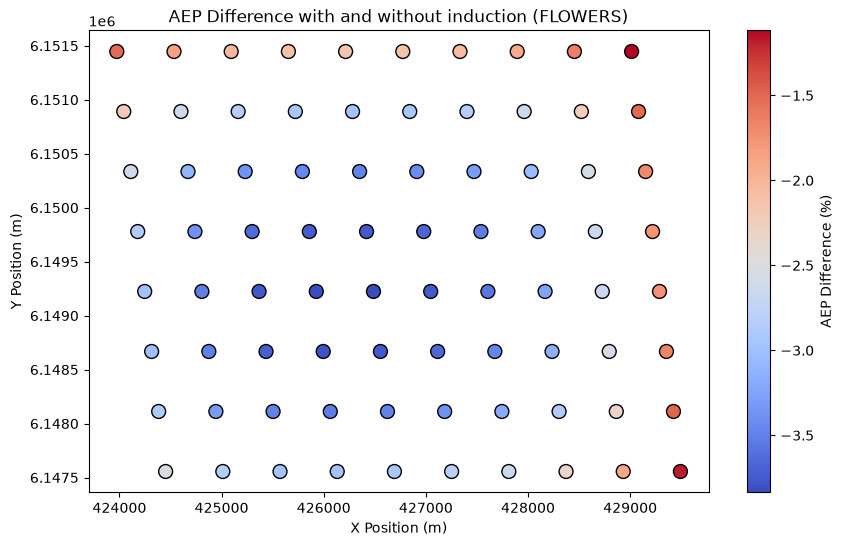

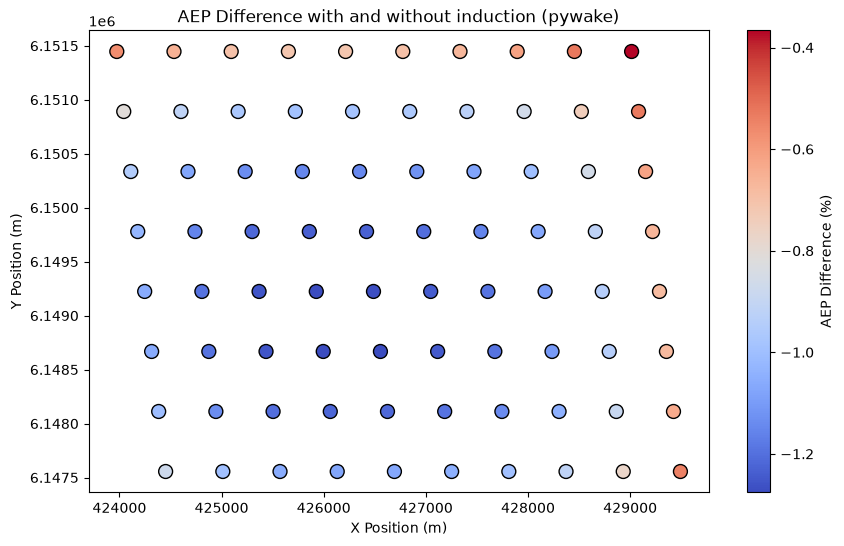

In [19]:
# FLOWERS
# Obtain the AEP per turbine with and without induction
aep_i_induction = wfm_fuga_induction.aep_i(x, y)
aep_i_no_induction = wfm_fuga_no_induction.aep_i(x, y)

# Compute the difference
aep_diff = (aep_i_induction - aep_i_no_induction)/aep_i_no_induction * 100  # Percentage difference

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=aep_diff, cmap='coolwarm', s=100, edgecolors='k')
plt.colorbar(label='AEP Difference (%)')
plt.title('AEP Difference with and without induction (FLOWERS)')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')

# PyWake
# Create the wind farm models with and without induction
wfm_pywake_induction = Ott_Nielsen_2014_Blockage(site=site,
                                                windTurbines=turbine,
                                                LUT_path=LUT_PATH)

wfm_pywake_no_induction = Ott_Nielsen_2014(site=site,
                                          windTurbines=turbine,
                                          LUT_path=LUT_PATH)

# Obtain the AEP per turbine with and without induction
sim_induction = wfm_pywake_induction(x, y)
aep_per_turbine_induction = sim_induction.aep().sum(["wd", "ws"])

sim_no_induction = wfm_pywake_no_induction(x, y)
aep_per_turbine_no_induction = sim_no_induction.aep().sum(["wd", "ws"])

# Compute the difference
aep_diff_pywake = (aep_per_turbine_induction - aep_per_turbine_no_induction) / aep_per_turbine_no_induction * 100  # Percentage difference

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=aep_diff_pywake, cmap='coolwarm', s=100, edgecolors='k')
plt.colorbar(label='AEP Difference (%)')
plt.title('AEP Difference with and without induction (pywake)')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
